In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Aquisição de dados**

Leitura do dataframe MICRODADOS_ENEM_2023

In [43]:
''' colunas = [
    'NU_INSCRICAO',

    #localização
    'SG_UF_PROVA',
    'NO_MUNICIPIO_PROVA',

    # perfil do aluno
    'TP_SEXO',
    'TP_COR_RACA',
    'TP_FAIXA_ETARIA',

    # escola
    'TP_ESCOLA',
    'TP_DEPENDENCIA_ADM_ESC',

    # renda
    'Q006',

    # notas
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'NU_NOTA_REDACAO',

    # presença
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT'
] '''

" colunas = [\n    'NU_INSCRICAO',\n\n    #localização\n    'SG_UF_PROVA',\n    'NO_MUNICIPIO_PROVA',\n\n    # perfil do aluno\n    'TP_SEXO',\n    'TP_COR_RACA',\n    'TP_FAIXA_ETARIA',\n\n    # escola\n    'TP_ESCOLA',\n    'TP_DEPENDENCIA_ADM_ESC',\n\n    # renda\n    'Q006',\n\n    # notas\n    'NU_NOTA_CN',\n    'NU_NOTA_CH',\n    'NU_NOTA_LC',\n    'NU_NOTA_MT',\n    'NU_NOTA_REDACAO',\n\n    # presença\n    'TP_PRESENCA_CN',\n    'TP_PRESENCA_CH',\n    'TP_PRESENCA_LC',\n    'TP_PRESENCA_MT'\n] "

In [44]:
'''
df = pd.read_csv(
    '../dados/microdados_enem_2023.csv',
    sep=';',
    encoding='latin-1',
    usecols=colunas
)
'''

"\ndf = pd.read_csv(\n    '../dados/microdados_enem_2023.csv',\n    sep=';',\n    encoding='latin-1',\n    usecols=colunas\n)\n"

Leitura do DataFrame ITENS_PROVA_2023

In [45]:
colunas_itens = [
    'SG_AREA',
    'CO_HABILIDADE',
    'IN_ITEM_ABAN',
    'NU_PARAM_A',
    'NU_PARAM_B',
    'NU_PARAM_C',
    'TX_COR'
]

In [46]:
df_itens = pd.read_csv(
    '../dados/ITENS_PROVA_2023.csv',
    sep=';',
    encoding='latin-1',
    usecols=colunas_itens
)

In [47]:
df_itens.head()

,SG_AREA,CO_HABILIDADE,IN_ITEM_ABAN,NU_PARAM_A,NU_PARAM_B,NU_PARAM_C,TX_COR
0,LC,14,0,2.20125,0.82582,0.21190,AMARELA
1,LC,23,0,2.43295,0.90091,0.13239,AMARELA
2,LC,26,0,1.95105,-0.13372,0.19557,AMARELA
3,LC,12,0,1.14733,0.38901,0.23027,ROSA
4,LC,8,0,2.25894,1.00728,0.17726,AMARELA


In [48]:
df_itens.shape

(5550, 7)

Criando um dataset tratado e menor do MICRODADOS_ENEM

In [49]:
'''
df.to_csv('../dados/enem_tratado.csv', index=False)
'''

"\ndf.to_csv('../dados/enem_tratado.csv', index=False)\n"

In [50]:
df_enem_tratado = pd.read_csv(
    '../dados/enem_tratado.csv',
    sep=',',
    encoding='latin-1',
)

In [51]:
df_enem_tratado.head(10)

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
0,210059085136,14,M,1,1,NaN,BrasÃ­lia,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,F
1,210059527735,12,M,1,1,NaN,BrasÃ­lia,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,H
2,210061103945,6,F,1,1,NaN,Caxias do Sul,RS,1,1,1,1,502.0,498.9,475.6,363.2,700.0,C
3,210060214087,2,F,3,2,2.0,Fortaleza,CE,1,1,1,1,459.0,508.5,507.2,466.7,880.0,C
4,210059980948,3,F,3,2,2.0,QuixadÃ¡,CE,1,1,1,1,402.5,379.2,446.9,338.3,560.0,B
5,210058061539,6,F,3,1,NaN,IlhÃ©us,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,C
6,210059855122,11,F,3,1,NaN,Petrolina,PE,0,0,0,0,NaN,NaN,NaN,NaN,NaN,C
7,210058387333,11,M,3,1,NaN,Governador Valadares,MG,0,0,0,0,NaN,NaN,NaN,NaN,NaN,A
8,210059085137,5,F,2,1,NaN,Salvador,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,C
9,210060801601,11,M,1,1,NaN,Batatais,SP,1,1,1,1,564.7,630.3,610.4,680.2,600.0,F


In [52]:
df_enem_tratado.shape

(3933955, 18)

**2. Integração de dados**

In [53]:
# 1. Preparação: Criamos a tabela de dificuldade média por Área
# Aqui pegamos o arquivo de ITENS e resumimos
df_dificuldade = df_itens.groupby('SG_AREA').agg({
    'NU_PARAM_B': 'mean'
}).reset_index()
df_dificuldade.columns = ['SG_AREA', 'DIFICULDADE_MEDIA']

# 2. O MERGE: Integrando as bases
# Vamos criar uma versão do df_enem que tenha uma linha para cada nota (CN, CH, LC, MT)
# para que o merge consiga "colar" a dificuldade correta em cada uma.
# Mas, para manter seu projeto simples e eficiente, vamos adicionar as 4 colunas de uma vez:

# Criamos um dicionário para mapear as dificuldades
mapa_dificuldade = df_dificuldade.set_index('SG_AREA')['DIFICULDADE_MEDIA'].to_dict()

# Criamos as novas colunas no seu DataFrame principal (df_final)
df_final = df_enem_tratado.copy()

df_final['DIF_MT'] = mapa_dificuldade.get('MT')
df_final['DIF_CN'] = mapa_dificuldade.get('CN')
df_final['DIF_CH'] = mapa_dificuldade.get('CH')
df_final['DIF_LC'] = mapa_dificuldade.get('LC')

In [54]:
df_final.head(10)

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,...,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,DIF_MT,DIF_CN,DIF_CH,DIF_LC
0,210059085136,14,M,1,1,NaN,BrasÃ­lia,DF,0,0,...,NaN,NaN,NaN,NaN,NaN,F,1.724463,1.41788,0.642594,0.661782
1,210059527735,12,M,1,1,NaN,BrasÃ­lia,DF,0,0,...,NaN,NaN,NaN,NaN,NaN,H,1.724463,1.41788,0.642594,0.661782
2,210061103945,6,F,1,1,NaN,Caxias do Sul,RS,1,1,...,502.0,498.9,475.6,363.2,700.0,C,1.724463,1.41788,0.642594,0.661782
3,210060214087,2,F,3,2,2.0,Fortaleza,CE,1,1,...,459.0,508.5,507.2,466.7,880.0,C,1.724463,1.41788,0.642594,0.661782
4,210059980948,3,F,3,2,2.0,QuixadÃ¡,CE,1,1,...,402.5,379.2,446.9,338.3,560.0,B,1.724463,1.41788,0.642594,0.661782
5,210058061539,6,F,3,1,NaN,IlhÃ©us,BA,0,0,...,NaN,NaN,NaN,NaN,NaN,C,1.724463,1.41788,0.642594,0.661782
6,210059855122,11,F,3,1,NaN,Petrolina,PE,0,0,...,NaN,NaN,NaN,NaN,NaN,C,1.724463,1.41788,0.642594,0.661782
7,210058387333,11,M,3,1,NaN,Governador Valadares,MG,0,0,...,NaN,NaN,NaN,NaN,NaN,A,1.724463,1.41788,0.642594,0.661782
8,210059085137,5,F,2,1,NaN,Salvador,BA,0,0,...,NaN,NaN,NaN,NaN,NaN,C,1.724463,1.41788,0.642594,0.661782
9,210060801601,11,M,1,1,NaN,Batatais,SP,1,1,...,564.7,630.3,610.4,680.2,600.0,F,1.724463,1.41788,0.642594,0.661782


**3. Limpeza e tratamento dos dados**

In [55]:
# Remove quem não tem nota em nenhuma das provas objetivas (faltosos/eliminados)
df_final = df_final.dropna(subset=['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT'])

In [56]:
#Substitui notas de redação nulas por 0 (quem entregou em branco)
df_final['NU_NOTA_REDACAO'] = df_final['NU_NOTA_REDACAO'].fillna(0)

In [57]:
# Padronização: Corrigir os nomes das cidades que estão com erro de acento
df_final['NO_MUNICIPIO_PROVA'] = df_final['NO_MUNICIPIO_PROVA'].str.encode('latin-1').str.decode('utf-8', errors='ignore')

In [58]:
#Substitui os valores numéricos da faixa etária por informacoes mais legíveis
dic_idade = {
    1: 'Menor de 17', 2: '17 anos', 3: '18 anos', 4: '19 anos',
    5: '20 anos', 6: '21 anos', 7: '22 anos', 8: '23 anos',
    9: '24 anos', 10: '25 anos', 11: '26-30 anos', 12: '31-35 anos',
    13: '36-40 anos', 14: '41-45 anos', 15: '46-50 anos', 
    16: '51-55 anos', 17: '56-60 anos', 18: '61-65 anos', 
    19: '66-70 anos', 20: 'Maior de 70'
}

df_final['TP_FAIXA_ETARIA'] = df_final['TP_FAIXA_ETARIA'].map(dic_idade)

In [59]:
# Substitui os valores numéricos da Cor/Raca por informacoes mais legíveis
dic_raca = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena',
    6: 'Sem inf'
}

df_final['TP_COR_RACA'] = df_final['TP_COR_RACA'].map(dic_raca)

In [60]:
# Substitui os valores numéricos da Escola por informacoes mais legíveis
dic_escola = {
    1: 'Não Inf',
    2: 'Pública',
    3: 'Privada'
}

df_final['TP_ESCOLA'] = df_final['TP_ESCOLA'].map(dic_escola)

In [61]:
# Substitui os valores numéricos da Administração da Escola por informacoes mais legíveis
dic_adm = {
    1: 'Federal',
    2: 'Estadual',
    3: 'Municipal',
    4: 'Privada'
}

df_final['TP_DEPENDENCIA_ADM_ESC'] = df_final['TP_DEPENDENCIA_ADM_ESC'].map(dic_adm)

df_final['TP_DEPENDENCIA_ADM_ESC'] = df_final['TP_DEPENDENCIA_ADM_ESC'].fillna('Não informado')

In [62]:
dic_presenca = {
    0: 'Faltou',
    1: 'Presente',
    2: 'Eliminado'
}

# 2. Aplicando nas 4 colunas de presença
colunas_presenca = ['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT']

for col in colunas_presenca:
    df_final[col] = df_final[col].map(dic_presenca)

In [63]:

dic_renda = {
    'A': 'Nenhuma Renda',
    'B': 'Até R$ 1.320',
    'C': 'R$ 1.320 - 1.980',
    'D': 'R$ 1.980 - 2.640',
    'E': 'R$ 2.640 - 3.300',
    'F': 'R$ 3.300 - 3.960',
    'G': 'R$ 3.960 - 5.280',
    'H': 'R$ 5.280 - 6.600',
    'I': 'R$ 6.600 - 7.920',
    'J': 'R$ 7.920 - 9.240',
    'K': 'R$ 9.240 - 10.560',
    'L': 'R$ 10.560 - 11.880',
    'M': 'R$ 11.880 - 13.200',
    'N': 'R$ 13.200 - 15.840',
    'O': 'R$ 15.840 - 19.800',
    'P': 'R$ 19.800 - 26.400',
    'Q': 'Acima de R$ 26.400'
}

df_final['Q006'] = df_final['Q006'].map(dic_renda)


In [64]:
df_final.head(20)

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,...,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,DIF_MT,DIF_CN,DIF_CH,DIF_LC
2,210061103945,21 anos,F,Branca,Não Inf,Não informado,Caxias do Sul,RS,Presente,Presente,...,502.0,498.9,475.6,363.2,700.0,R$ 1.320 - 1.980,1.724463,1.41788,0.642594,0.661782
3,210060214087,17 anos,F,Parda,Pública,Estadual,Fortaleza,CE,Presente,Presente,...,459.0,508.5,507.2,466.7,880.0,R$ 1.320 - 1.980,1.724463,1.41788,0.642594,0.661782
4,210059980948,18 anos,F,Parda,Pública,Estadual,Quixadá,CE,Presente,Presente,...,402.5,379.2,446.9,338.3,560.0,Até R$ 1.320,1.724463,1.41788,0.642594,0.661782
9,210060801601,26-30 anos,M,Branca,Não Inf,Não informado,Batatais,SP,Presente,Presente,...,564.7,630.3,610.4,680.2,600.0,R$ 3.300 - 3.960,1.724463,1.41788,0.642594,0.661782
10,210059085130,23 anos,M,Parda,Não Inf,Não informado,Natal,RN,Presente,Presente,...,644.9,620.2,626.9,736.3,860.0,Até R$ 1.320,1.724463,1.41788,0.642594,0.661782
11,210060801595,18 anos,M,Parda,Pública,Estadual,Ubiratã,PR,Presente,Presente,...,608.2,667.6,607.9,691.9,780.0,R$ 1.980 - 2.640,1.724463,1.41788,0.642594,0.661782
13,210060214081,18 anos,F,Branca,Não Inf,Não informado,São Paulo,SP,Presente,Presente,...,626.5,604.9,614.3,548.8,800.0,R$ 1.320 - 1.980,1.724463,1.41788,0.642594,0.661782
14,210059388087,26-30 anos,F,Preta,Não Inf,Não informado,Recife,PE,Presente,Presente,...,547.2,623.3,593.7,404.6,560.0,Até R$ 1.320,1.724463,1.41788,0.642594,0.661782
15,210059980942,22 anos,F,Parda,Não Inf,Não informado,Caraúbas,RN,Presente,Presente,...,510.8,313.4,388.5,415.6,560.0,Nenhuma Renda,1.724463,1.41788,0.642594,0.661782
16,210058061534,19 anos,F,Branca,Pública,Estadual,Belém,PA,Presente,Presente,...,515.7,553.1,544.4,437.0,880.0,Até R$ 1.320,1.724463,1.41788,0.642594,0.661782


**4. Transformação de dados**

In [ ]:
# Criando média geral das provas
df_final['MEDIA_GERAL'] = (
    df_final['NU_NOTA_CN'] +
    df_final['NU_NOTA_CH'] +
    df_final['NU_NOTA_LC'] +
    df_final['NU_NOTA_MT'] +
    df_final['NU_NOTA_REDACAO']
) / 5

df_final[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'MEDIA_GERAL', 'NU_NOTA_REDACAO']].head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,MEDIA_GERAL,NU_NOTA_REDACAO
2,502.0,498.9,475.6,363.2,507.94,700.0
3,459.0,508.5,507.2,466.7,564.28,880.0
4,402.5,379.2,446.9,338.3,425.38,560.0
9,564.7,630.3,610.4,680.2,617.12,600.0
10,644.9,620.2,626.9,736.3,697.66,860.0


In [66]:
# Criando classificação de desempenho
def classificar_desempenho(media):
    if media < 450:
        return 'Baixo'
    elif media < 650:
        return 'Médio'
    else:
        return 'Alto'

df_final['DESEMPENHO'] = df_final['MEDIA_GERAL'].apply(classificar_desempenho)
df_final[['MEDIA_GERAL', 'DESEMPENHO']].head()

,MEDIA_GERAL,DESEMPENHO
2,507.94,Médio
3,564.28,Médio
4,425.38,Baixo
9,617.12,Médio
10,697.66,Alto


In [67]:
# Verificando presença total nas provas
df_final['PRESENCA_TOTAL'] = (
    (df_final['TP_PRESENCA_CN'] == 'Presente') &
    (df_final['TP_PRESENCA_CH'] == 'Presente') &
    (df_final['TP_PRESENCA_LC'] == 'Presente') &
    (df_final['TP_PRESENCA_MT'] == 'Presente')
)

df_final['PRESENCA_TOTAL'] = df_final['PRESENCA_TOTAL'].map({
    True: 'Participou de tudo',
    False: 'Faltou em alguma prova'
})

df_final[['PRESENCA_TOTAL']].head()

,PRESENCA_TOTAL
2,Participou de tudo
3,Participou de tudo
4,Participou de tudo
9,Participou de tudo
10,Participou de tudo


In [68]:
# Média por tipo de escola
media_escola = df_final.groupby('TP_ESCOLA')['MEDIA_GERAL'].mean().reset_index()

media_escola

,TP_ESCOLA,MEDIA_GERAL
0,Não Inf,542.994410
1,Privada,616.089247
2,Pública,515.789085


In [69]:
# Média por estado
media_estado = df_final.groupby('SG_UF_PROVA')['MEDIA_GERAL'].mean().reset_index()
media_estado = media_estado.sort_values(by='MEDIA_GERAL', ascending=False)

media_estado.head(10)

,SG_UF_PROVA,MEDIA_GERAL
10,MG,565.139710
25,SP,564.922074
23,SC,559.620816
6,DF,558.867516
22,RS,557.564071
7,ES,556.553018
18,RJ,555.994894
17,PR,550.064677
8,GO,542.793834
19,RN,536.940815


In [70]:
# Salvando dataset transformado
df_final.to_csv('../dados/enem_transformado.csv', index=False)

**5. Análise exploratória**

C:\Users\laris\AppData\Local\Temp\ipykernel_19672\2225441056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


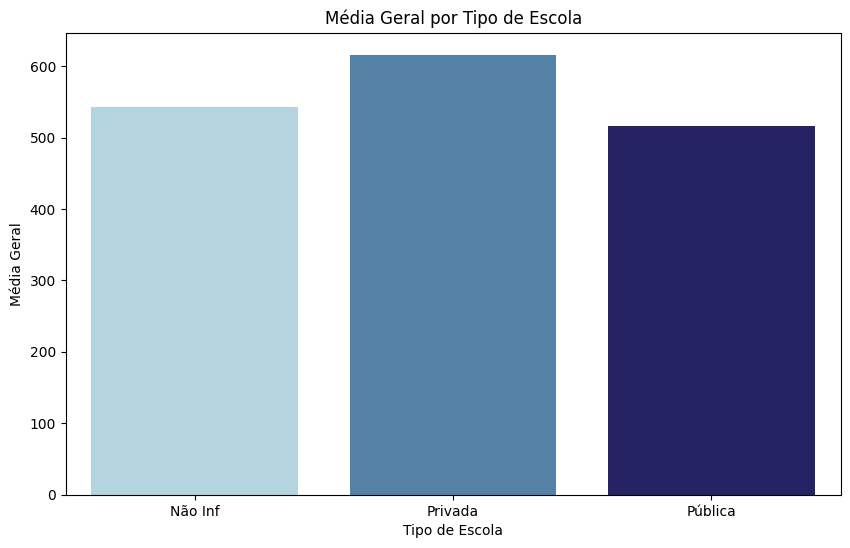

In [ ]:
# Gráfico de média por tipo de escola
media_escola = df_final.groupby('TP_ESCOLA')['MEDIA_GERAL'].mean().reset_index()

cores = ['lightblue', 'steelblue', 'midnightblue']

plt.figure(figsize=(10,6))

sns.barplot(
    data=media_escola,
    x='TP_ESCOLA',
    y='MEDIA_GERAL',
    palette=cores
)

plt.title('Média Geral por Tipo de Escola')
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral')

plt.show()

**Insight**

Os alunos de escolas privadas apresentaram média geral superior aos alunos de escolas públicas. Isso pode estar relacionado ao maior acesso a recursos educacionais, preparação para vestibulares e melhores condições de estudo.

Esse resultado é relevante porque evidencia desigualdades educacionais que impactam diretamente o desempenho dos estudantes no ENEM.

In [160]:
ordem_renda = [
    'Nenhuma Renda',
    'Até R$ 1.320',
    'R$ 1.320 - 1.980',
    'R$ 1.980 - 2.640',
    'R$ 2.640 - 3.300',
    'R$ 3.300 - 3.960',
    'R$ 3.960 - 5.280',
    'R$ 5.280 - 6.600',
    'R$ 6.600 - 7.920',
    'R$ 7.920 - 9.240',
    'R$ 9.240 - 10.560',
    'R$ 10.560 - 11.880',
    'R$ 11.880 - 13.200',
    'R$ 13.200 - 15.840',
    'R$ 15.840 - 19.800',
    'R$ 19.800 - 26.400',
    'Acima de R$ 26.400'
]

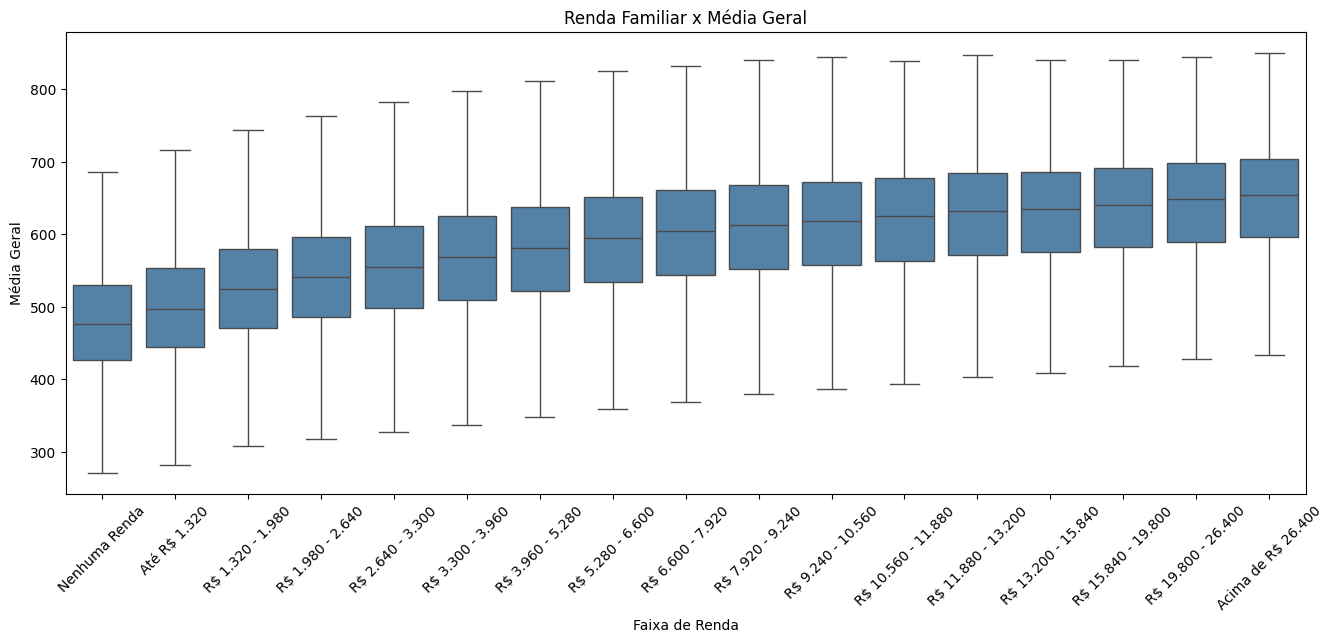

In [181]:
plt.figure(figsize=(16,6))

sns.boxplot(
    x='Q006',
    y='MEDIA_GERAL',
    data=df_final,
    order=ordem_renda,
    showfliers=False,
    color='steelblue'
)

plt.title('Renda Familiar x Média Geral')
plt.xlabel('Faixa de Renda')
plt.ylabel('Média Geral')

plt.xticks(rotation=45)

plt.show()

**Insight**

Foi possível identificar que candidatos com maior renda familiar tendem a obter médias mais altas no exame.

Isso ocorre porque fatores financeiros podem proporcionar melhores oportunidades de estudo, acesso à internet, cursos preparatórios e materiais educacionais.

A análise é importante para compreender como fatores socioeconômicos influenciam o desempenho acadêmico.

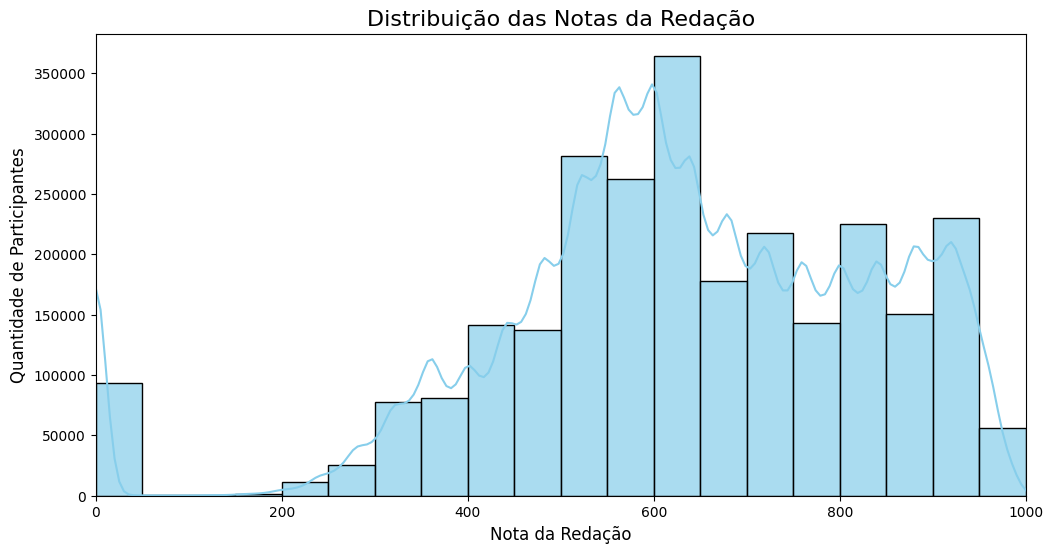

In [179]:
#Gráfico de distribuição das médias gerais
plt.figure(figsize=(12,6))

sns.histplot(
    df_final['NU_NOTA_REDACAO'],
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.7,
)

plt.title('Distribuição das Notas da Redação', fontsize=16)
plt.xlabel('Nota da Redação', fontsize=12)
plt.ylabel('Quantidade de Participantes', fontsize=12)

plt.xlim(0, 1000)

plt.show()

**Insight**

Observou-se maior concentração de candidatos em notas intermediárias da redação, enquanto notas extremamente altas apareceram em menor quantidade. Isso demonstra que alcançar desempenhos elevados na redação exige domínio de competências específicas de escrita e argumentação.

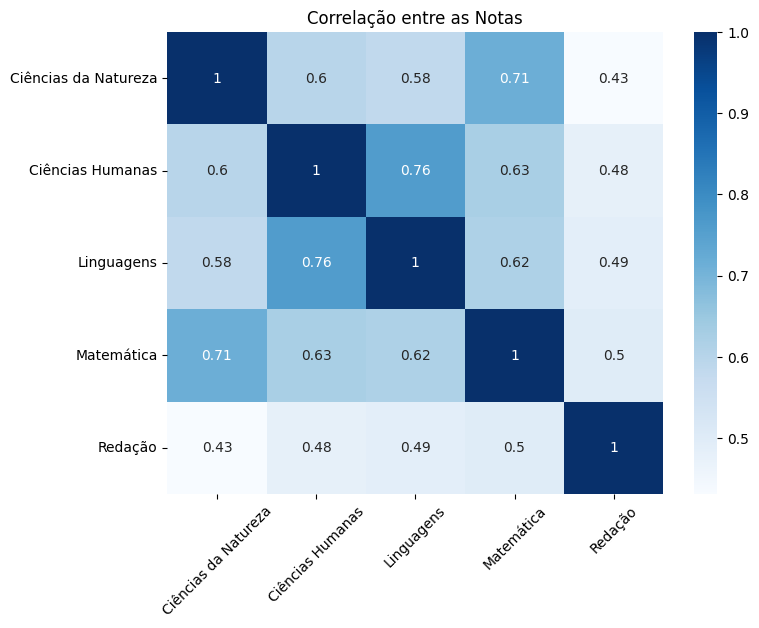

In [158]:
# Gráfico de correlação entre as áreas de conhecimento
correlacao = df_final[
    [
        'NU_NOTA_CN',
        'NU_NOTA_CH',
        'NU_NOTA_LC',
        'NU_NOTA_MT',
        'NU_NOTA_REDACAO'
    ]
].rename(columns={
    'NU_NOTA_CN': 'Ciências da Natureza',
    'NU_NOTA_CH': 'Ciências Humanas',
    'NU_NOTA_LC': 'Linguagens',
    'NU_NOTA_MT': 'Matemática',
    'NU_NOTA_REDACAO': 'Redação'
}).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues'
)
plt.xticks(rotation=45)

plt.title('Correlação entre as Notas')

plt.show()

**Insight**

A análise mostrou que alunos com bom desempenho em uma área geralmente também apresentam boas notas em outras disciplinas.

Isso sugere que hábitos de estudo, preparação e dedicação influenciam o desempenho geral do candidato.

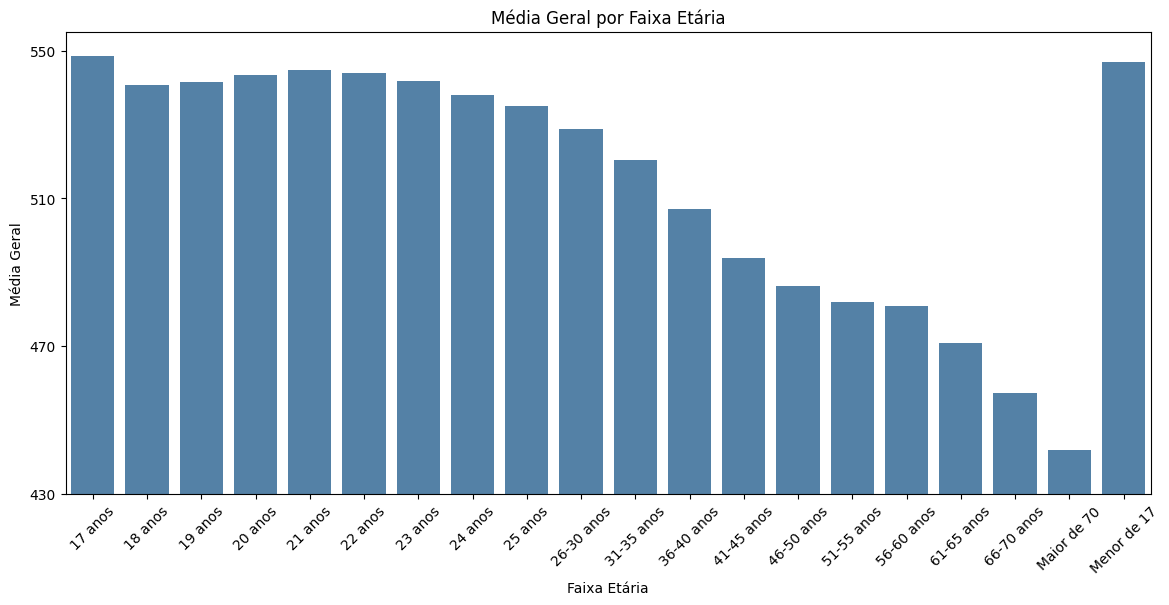

In [184]:
# Gráfico de média por faixa etária
media_idade = df_final.groupby('TP_FAIXA_ETARIA')['MEDIA_GERAL'].mean().reset_index()

plt.figure(figsize=(14,6))

sns.barplot(
    data=media_idade,
    x='TP_FAIXA_ETARIA',
    y='MEDIA_GERAL',
    color='steelblue'
)

plt.title('Média Geral por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Média Geral')

plt.xticks(rotation=45)
plt.yticks(range(430, 556, 40))
plt.ylim(430, 555)


plt.show()

**Insight**

Os participantes mais jovens apresentaram médias ligeiramente superiores em relação às faixas etárias mais altas.

Isso pode ocorrer porque estudantes recém-saídos do ensino médio ainda possuem maior contato com os conteúdos cobrados no exame.

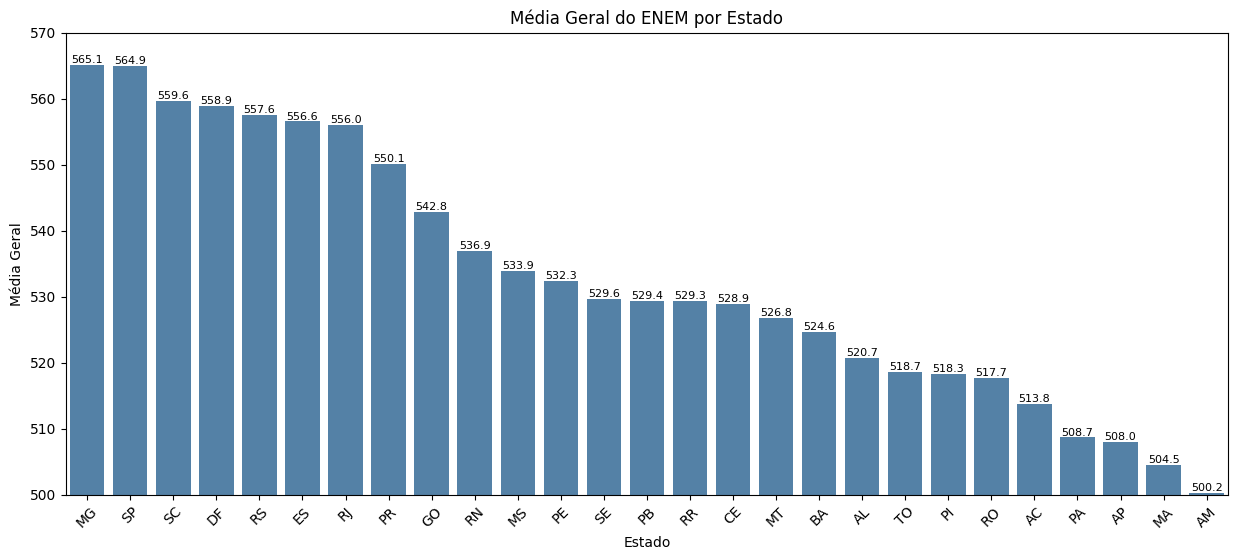

In [ ]:
#Gráfico media por estado
plt.figure(figsize=(15,6))

ax = sns.barplot(
    data=media_estado,
    x='SG_UF_PROVA',
    y='MEDIA_GERAL',
    color='steelblue'
)

for barra in ax.patches:

    altura = barra.get_height()

    ax.annotate(
        f'{altura:.1f}',
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Média Geral do ENEM por Estado')
plt.xlabel('Estado')
plt.ylabel('Média Geral')

plt.xticks(rotation=45)
plt.yticks(range(500, 571, 10))
plt.ylim(500, 570)

plt.show()

**Insight**

A análise mostrou diferenças significativas entre as médias dos estados brasileiros no ENEM. Alguns estados apresentaram desempenho superior em relação a outros, evidenciando desigualdades regionais na educação.

Essas diferenças podem estar relacionadas a fatores como investimento em educação, condições socioeconômicas, infraestrutura escolar e acesso a oportunidades de aprendizagem.

Esse gráfico é relevante porque permite visualizar padrões regionais e compreender como a localização geográfica pode impactar o desempenho dos estudantes no exame.